
# Duck Typing for MFML

This example demonstrates the "duck typing" flexibility of the ``ModelMFML``
orchestrator. DUck typing is summarized well with 'If it walks like a duck, swims like a duck, and wualks like a duck, it must be a duck.'
Here, we use it to mean that we can use any ML architecture that has certain attributes.
While MFML-QC provides an ultra-fast, built-in Kernel Ridge
Regressor (KRR), you are not forced into using it.

Because the ModelMFML class is flexible, you can pass any custom machine
learning model (such as a Neural Network or Random Forest from ``scikit-learn``)
using the ``base_estimator`` argument, provided it has standard ``.fit(X, y)`` or ``.train(X,y)``,
and ``.predict(X)`` methods!

.. sphinx_gallery_thumbnail_path = '_static/ducktyping.png'


## Imports and Helper Functions
We reuse the exact same helper functions from the previous tutorial to extract
and strictly nest our multi-fidelity training data.



In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mfml_qc.datasets import load_benzene_data
from mfml_qc.mfml import ModelMFML
from mfml_qc.utils import build_hierarchy_arrays, top_down_subsetting

# Import a completely different algorithm from scikit-learn
from sklearn.ensemble import RandomForestRegressor

/home/vvinod/miniforge3/envs/mfmlenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading and Splitting Data



In [2]:
dataset = load_benzene_data()

X_CM = dataset["X_CM"]
data = dataset["energies"]

hierarchy_cols = [2, 3, 6, 7]
num_fids = len(hierarchy_cols)

train_mask = data[:, 0] < 12288
test_mask = data[:, 0] >= 12288

X_train_parent = X_CM[train_mask]
X_test = X_CM[test_mask]
data_train = data[train_mask]
data_test = data[test_mask]

y_trains, indexes, means = build_hierarchy_arrays(data_train, hierarchy_cols)

# We use the same target sample sizes as the previous tutorial
n_trains_target = [1024, 512, 256, 128]
subset_y_trains, subset_indexes = top_down_subsetting(
    y_trains, indexes, n_trains_target, seed=42
)

## Passing a Custom Base Estimator
Instead of initializing the default Kernel Ridge Regressor, we will initialize
a Random Forest Regressor from ``scikit-learn``.
Before we get into the code, let's briefly review the mechanics of a
Random Forest Regressor. Unlike Kernel Ridge Regression, which relies on
measuring continuous structural distances (kernels), a Random Forest is an
ensemble method constructed from multiple decision trees.

For a given input geometry representation $x$, each individual decision
tree $k$ in the forest makes an independent prediction $h_k(x)$.
The final ensemble prediction $\hat{y}$ is simply the average of all
$K$ trees:

\begin{align}\hat{y}(x) = \frac{1}{K} \sum_{k=1}^{K} h_k(x)\end{align}

By training each tree on a random subset of the data (bootstrapping) and
considering a random subset of features at each split, the Random Forest
drastically reduces the variance and overfitting that is common in single
decision trees.

Notice how we pass the initialized ``sk_model`` directly to the ``base_estimator``
argument of the ``ModelMFML`` orchestrator. The orchestrator will automatically
duplicate this tree-based model for all 2N-1 required combinations!



In [3]:
sk_model = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)

# the mfml model class takes the random forest regressor as the base-estimator
mfml_model = ModelMFML(base_estimator=sk_model, p_bar=False)

# The orchestrator handles calling `.fit()` on the Random Forest models natively
mfml_model.train(
    X_train_parent=X_train_parent, y_trains=subset_y_trains, indexes=subset_indexes
)

Extracting X_trains:   0%|                                                                 | 0/4 [00:00<?, ?it/s]

Extracting upper y_trains:   0%|                                                           | 0/4 [00:00<?, ?it/s]

Extracting lower y_trains:   0%|                                                           | 0/3 [00:00<?, ?it/s]

Training upper ML models...:   0%|                                                         | 0/4 [00:00<?, ?it/s]

Training upper ML models...:  25%|████████████▎                                    | 1/4 [00:00<00:00,  6.00it/s]

Training upper ML models...:  50%|████████████████████████▌                        | 2/4 [00:00<00:00,  7.48it/s]

Training upper ML models...:  75%|████████████████████████████████████▊            | 3/4 [00:00<00:00,  8.32it/s]

Training upper ML models...: 100%|█████████████████████████████████████████████████| 4/4 [00:00<00:00,  8.82it/s]

Training lower ML models:   0%|                                                            | 0/3 [00:00<?, ?it/s]

Training lower ML models:  67%|██████████████████████████████████▋                 | 2/3 [00:00<00:00, 11.25it/s]

## Predicting and Evaluating



In [4]:
y_test_true = data_test[:, hierarchy_cols[-1]]

preds = mfml_model.predict(X_test=X_test, optimiser="default")

# Un-center the predictions
preds += means[-1]

mae = np.mean(np.abs(preds - y_test_true))
mae_kcal = mae * 23  # eV to kcal/mol

print(f"MFML (Random Forest) Test Set MAE: {mae:.6f} eV ({mae_kcal:.4f} kcal/mol)")

Upper MFML predictions:   0%|                                                              | 0/4 [00:00<?, ?it/s]

Lower MFML predictions:   0%|                                                              | 0/3 [00:00<?, ?it/s]

MFML (Random Forest) Test Set MAE: 0.029552 eV (0.6797 kcal/mol)


## Parity Plot
We can visualize the performance of our Random Forest-based MFML model.
While kernels generally perform better for molecular representations like
the Coulomb Matrix, this proves the framework is completely model-agnostic!



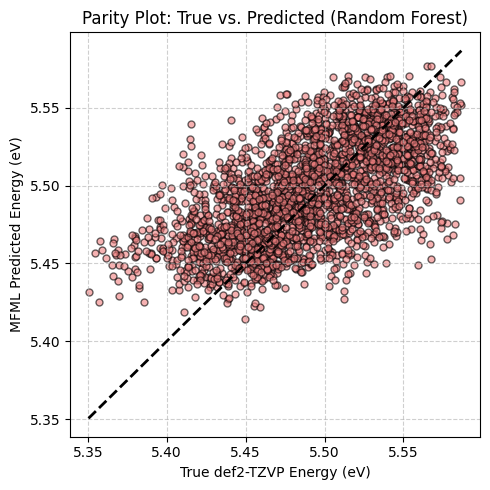

In [5]:
plt.figure(figsize=(5, 5))

# Plot the scatter points
plt.scatter(y_test_true, preds, alpha=0.6, color="lightcoral", edgecolor="k", s=25)

# Calculate the limits to draw a perfect 45-degree diagonal line
min_val = min(np.min(y_test_true), np.min(preds))
max_val = max(np.max(y_test_true), np.max(preds))
plt.plot([min_val, max_val], [min_val, max_val], "k--", lw=2)

plt.xlabel("True def2-TZVP Energy (eV)")
plt.ylabel("MFML Predicted Energy (eV)")
plt.title("Parity Plot: True vs. Predicted (Random Forest)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()